### Housing

This notebook performs transfer leanring on two Housing datasets, where similar columns are used!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import random
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
from utils import *
from baselines import *
import xgboost as xgb
from sklearn.model_selection import train_test_split
import itertools

In [2]:
seed_list = [1,2,3,4,5]
splitting_variable_list = ['CRIM', 'PTRATIO', 'LSTAT']

In [3]:
data = pd.read_csv('../datasets/boston-housing.csv')
data.columns

#data = data.dropna()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].astype('category').cat.codes
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [4]:
#print correlations with target
target_column = 'MEDV'
correlations = data.corr()[target_column].drop(target_column)
print(correlations)
data.columns


CRIM      -0.391363
ZN         0.373136
INDUS     -0.481772
CHAS       0.181391
NOX       -0.427321
RM         0.695360
AGE       -0.394656
DIS        0.249929
RAD       -0.381626
TAX       -0.468536
PTRATIO   -0.507787
B          0.333461
LSTAT     -0.735822
Name: MEDV, dtype: float64


Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [5]:
#order based on this variable
data_ = data.sort_values(by=splitting_variable)
#remove this variable now
data_ = data_.drop(columns = splitting_variable)
#divide into source and target data
data_source = data_[0:int(len(data) / 2)]
data_target = data_[int(len(data) / 2):]

predictor_columns = [col for col in data_.columns if col != target_column]


NameError: name 'splitting_variable' is not defined

(array([21., 39., 75., 77., 29.,  7.,  2.,  2.,  0.,  1.]),
 array([ 5.  ,  9.17, 13.34, 17.51, 21.68, 25.85, 30.02, 34.19, 38.36,
        42.53, 46.7 ]),
 <BarContainer object of 10 artists>)

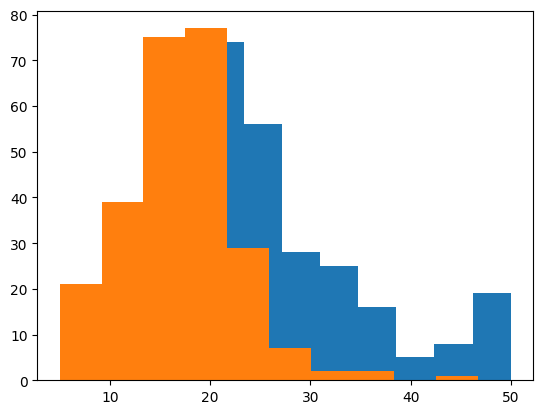

In [ ]:
#show a histogram of predictor variables between source and target
plt.hist(data_source['MEDV'])
plt.hist(data_target['MEDV'])

In [ ]:
#Split target into train, val, test

data_target_train, data_target_temp = train_test_split(data_target, test_size = 0.602, random_state=seed)
data_target_val, data_target_test = train_test_split(data_target_temp, test_size = 0.5, random_state=seed)
print(len(data_target_train), len(data_target_val), len(data_target_test))

X_source_train, y_source_train = np.array(data_source[predictor_columns], dtype=float), np.array(data_source[target_column])

X_target_train, y_target_train = np.array(data_target_train[predictor_columns], dtype=float), np.array(data_target_train[target_column])
X_target_val, y_target_val = np.array(data_target_val[predictor_columns], dtype=float), np.array(data_target_val[target_column])
X_target_test, y_target_test = np.array(data_target_test[predictor_columns], dtype=float), np.array(data_target_test[target_column])


100 76 77


In [6]:
#ablation study for LSTransferTreeBoost with Gaussian errors, with gaussian source domain errors
ablation_transfer_housing = pd.DataFrame(columns = ['seed', 'splitting_variable', 'method', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0', 
                                                          'val_rmse', 'val_mae', 'rmse', 'mae'])
v_list = [0.05, 0.1]
source_tree_size_list = [1,2]
target_tree_size_list = [1,2]
k_list = [0.01, 0.05]
m_0_list = [0.5, 0.9]


# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    k_list,
    m_0_list
))

for seed in seed_list:
    for splitting_variable in splitting_variable_list:
    
        #order based on this variable
        data_ = data.sort_values(by=splitting_variable)
        #remove this variable now
        data_ = data_.drop(columns = splitting_variable)
        #divide into source and target data
        data_source = data_[0:int(len(data_) / 2)]
        data_target = data_[int(len(data_) / 2):]

        predictor_columns = [col for col in data_.columns if col != target_column]

        #Split target into train, val, test

        data_target_train, data_target_temp = train_test_split(data_target, test_size = 0.602, random_state=seed)
        data_target_val, data_target_test = train_test_split(data_target_temp, test_size = 0.5, random_state=seed)
        print(len(data_target_train), len(data_target_val), len(data_target_test))

        X_source_train, y_source_train = np.array(data_source[predictor_columns], dtype=float), np.array(data_source[target_column])

        X_target_train, y_target_train = np.array(data_target_train[predictor_columns], dtype=float), np.array(data_target_train[target_column])
        X_target_val, y_target_val = np.array(data_target_val[predictor_columns], dtype=float), np.array(data_target_val[target_column])
        X_target_test, y_target_test = np.array(data_target_test[predictor_columns], dtype=float), np.array(data_target_test[target_column])
        for config in param_grid:
            v, source_tree_size, target_tree_size, k, m_0 = config


            #Test for all methods!!!!

            method = f'LSTransferTreeBoost'
            fiter = LSTransferTreeBoost(epochs=1000, v=v, source_tree_size=source_tree_size, 
                                    target_tree_size=target_tree_size, k=k, m_0=m_0)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=8, show_curves=False)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
            val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
            ablation_transfer_housing.loc[len(ablation_transfer_housing)] = [seed, splitting_variable, method, v, source_tree_size, target_tree_size, k, m_0, val_rmse, val_mae, rmse, mae]
            ablation_transfer_housing.to_csv(f'results/LSTransferTreeBoost_ablation_housing.csv')





                            
        



100 76 77


KeyboardInterrupt: 

In [ ]:
#ablation study for transfertreeboost Gaussian errors, with gaussian source domain errors
ablation_transfer_housing = pd.DataFrame(columns = ['seed', 'splitting_variable', 'method',
                                   'v', 'target_tree_size', 'val_rmse', 'val_mae', 'rmse', 'mae'])

v_list = [0.01, 0.02, 0.05, 0.1, 0.15]
target_tree_size_list = [1,2,3,4]

# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    target_tree_size_list
))



for seed in seed_list:
    for splitting_variable in splitting_variable_list:
    
        #order based on this variable
        data_ = data.sort_values(by=splitting_variable)
        #remove this variable now
        data_ = data_.drop(columns = splitting_variable)
        #divide into source and target data
        data_source = data_[0:int(len(data_) / 2)]
        data_target = data_[int(len(data_) / 2):]

        predictor_columns = [col for col in data_.columns if col != target_column]

        #Split target into train, val, test

        data_target_train, data_target_temp = train_test_split(data_target, test_size = 0.602, random_state=seed)
        data_target_val, data_target_test = train_test_split(data_target_temp, test_size = 0.5, random_state=seed)
        print(len(data_target_train), len(data_target_val), len(data_target_test))

        X_source_train, y_source_train = np.array(data_source[predictor_columns], dtype=float), np.array(data_source[target_column])

        X_target_train, y_target_train = np.array(data_target_train[predictor_columns], dtype=float), np.array(data_target_train[target_column])
        X_target_val, y_target_val = np.array(data_target_val[predictor_columns], dtype=float), np.array(data_target_val[target_column])
        X_target_test, y_target_test = np.array(data_target_test[predictor_columns], dtype=float), np.array(data_target_test[target_column])
        for config in param_grid:
            v, target_tree_size = config


            method = 'xgboost'
            params = {
                'objective': 'reg:squarederror',  # Regression with squared error
                'max_depth': target_tree_size,                   # Maximum depth of a tree
                'eta': v,                       # Learning rate
                'eval_metric': 'rmse',           # RMSE as evaluation metric
                }
                    
            bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=1000, params=params)
            preds_val = test_xgboost(X_target_val, bst)
            val_rmse = compute_rmse(preds_val, y_target_val)
            val_mae = compute_mae(preds_val, y_target_val)
            preds = test_xgboost(X_target_test, bst)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            ablation_transfer_housing.loc[len(ablation_transfer_housing)] = [seed, splitting_variable, method, v, target_tree_size, val_rmse, val_mae,
                                                                                            rmse,mae]
            
            ablation_transfer_housing.to_csv(f'results/xgboost_ablation_housing.csv')

            method = 'xgboost_naive_transfer'
            params = {
                'objective': 'reg:squarederror',  # Regression with squared error
                'max_depth': target_tree_size,                   # Maximum depth of a tree
                'eta': v,                       # Learning rate
                'eval_metric': 'rmse',           # RMSE as evaluation metric
                }
            X_comb = np.concatenate((X_target_train, X_source_train)) 
            y_comb = np.concatenate((y_target_train, y_source_train))       
            bst = train_xgboost(X_comb, y_comb, X_target_val, y_target_val, boosting_rounds=1000, params=params)
            preds_val = test_xgboost(X_target_val, bst)
            val_rmse = compute_rmse(preds_val, y_target_val)
            val_mae = compute_mae(preds_val, y_target_val)
            preds = test_xgboost(X_target_test, bst)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            ablation_transfer_housing.loc[len(ablation_transfer_housing)] = [seed, splitting_variable, method, v, target_tree_size, val_rmse, val_mae,
                                                                                            rmse,mae]
            
            ablation_transfer_housing.to_csv(f'results/xgboost_ablation_housing.csv')
                                
            

